#Transfer Learning
##CIFAR-10: Freeze vs. Fine-Tune vs. Train-from-Scratch

In this lab we will:
1. **Inspect** a pretrained DenseNet121 base model.  
2. **Freeze** that base, **add** a new head, and **train** only the head.  
3. **Unfreeze** the entire model and **fine-tune**.  
4. **Custom-freeze** the first N layers, train the rest.  
5. Build & train a small **custom CNN** from scratch.  
6. **Compare** validation accuracies across all five runs.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
print("TF version:", tf.__version__)

TF version: 2.18.0


In [ ]:
# Load CIFAR-10 Dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
# Convert labels to categorical
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)
print("Shapes:", x_train.shape, "→", y_train.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Shapes: (50000, 32, 32, 3) → (50000, 10)


In [ ]:
y_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]])

In [ ]:
def build_tl_model(base_cls):
    """Build a transfer-learning model using the given base."""
    base = base_cls(include_top=False, weights='imagenet',
                    input_shape=(32, 32, 3))

    # 2) Freeze only the base
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [ ]:
# Freeze all layers and train head only
model_fe = build_tl_model(tf.keras.applications.DenseNet121)
model_fe.summary()

# Verify trainable counts
print("Total layers:", len(model_fe.layers))
print("Trainable layers:", sum(l.trainable for l in model_fe.layers))

model_fe.compile(tf.keras.optimizers.Adam(1e-3),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

history_fe = model_fe.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1, 1, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,169,994 (27.35 MB)

 Trainable params: 132,490 (517.54 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Total layers: 4
Trainable layers: 3
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 32ms/step - accuracy: 0.5107 - loss: 1.4042 - val_accuracy: 0.6103 - val_loss: 1.1084
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.6358 - loss: 1.0320 - val_accuracy: 0.6266 - val_loss: 1.0702
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 12ms/step - accuracy: 0.6628 - loss: 0.9555 - val_accuracy: 0.6348 - val_loss: 1.0587
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6812 - loss: 0.9009 - val_accuracy: 0.6363 - val_loss: 1.0593
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6942 - loss: 0.8605 - val_accuracy: 0.6441 - val_loss: 1.0433


In [ ]:
# Unfreeze entire model and fine-tune
model_ft = model_fe

for layer in model_ft.layers:
    layer.trainable = True

model_ft.summary()

model_ft.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history_ft = model_ft.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1, 1, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,434,976 (28.36 MB)

 Trainable params: 7,086,346 (27.03 MB)

 Non-trainable params: 83,648 (326.75 KB)

 Optimizer params: 264,982 (1.01 MB)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 270s 91ms/step - accuracy: 0.3725 - loss: 1.9739 - val_accuracy: 0.5274 - val_loss: 1.4738
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 111s 35ms/step - accuracy: 0.5563 - loss: 1.2795 - val_accuracy: 0.6106 - val_loss: 1.1553
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 36ms/step - accuracy: 0.6302 - loss: 1.0570 - val_accuracy: 0.6590 - val_loss: 1.0132
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 35ms/step - accuracy: 0.6819 - loss: 0.9129 - val_accuracy: 0.6949 - val_loss: 0.8927
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 35ms/step - accuracy: 0.7194 - loss: 0.8038 - val_accuracy: 0.7166 - val_loss: 0.8386


In [ ]:
# Fine-tune all layers from scratch (no initial freeze)
model_nf = build_tl_model(tf.keras.applications.DenseNet121)
model_nf.trainable = True
model_nf.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("=== Fine-tune all layers (no initial freeze) ===")
history_nf = model_nf.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

=== Fine-tune all layers (no initial freeze) ===
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 29ms/step - accuracy: 0.4023 - loss: 1.7199 - val_accuracy: 0.5715 - val_loss: 1.2335
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 13ms/step - accuracy: 0.5916 - loss: 1.1855 - val_accuracy: 0.6095 - val_loss: 1.1351
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - accuracy: 0.6234 - loss: 1.0827 - val_accuracy: 0.6246 - val_loss: 1.0891
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 15ms/step - accuracy: 0.6415 - loss: 1.0328 - val_accuracy: 0.6336 - val_loss: 1.0665
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 12ms/step - accuracy: 0.6540 - loss: 1.0008 - val_accuracy: 0.6310 - val_loss: 1.0648


In [ ]:
# Custom-freeze first 100 layers

# 1) Instantiate the backbone first
base = tf.keras.applications.DenseNet121(
    include_top=False,
    weights="imagenet",
    input_shape=(32, 32, 3)
)

# 2) Freeze the first 100 layers of the backbone
for layer in base.layers[:100]:
    layer.trainable = False
for layer in base.layers[100:]:
    layer.trainable = True

model_cf = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])


# 4) Compile & verify
model_cf.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Count how many layers are trainable
trainable = sum(l.trainable for l in model_cf.layers + base.layers)
total     = sum(1 for _ in model_cf.layers + base.layers)
print(f"Trainable layers: {trainable} / {total}")

# 5) Train on your resized CIFAR inputs
history_cf = model_cf.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)


Trainable layers: 331 / 431
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 224s 76ms/step - accuracy: 0.4830 - loss: 1.5048 - val_accuracy: 0.7306 - val_loss: 0.9113
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.7554 - loss: 0.7078 - val_accuracy: 0.7814 - val_loss: 0.6363
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 33ms/step - accuracy: 0.8206 - loss: 0.5185 - val_accuracy: 0.7978 - val_loss: 0.5982
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 31ms/step - accuracy: 0.8685 - loss: 0.3845 - val_accuracy: 0.7995 - val_loss: 0.6192
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9037 - loss: 0.2825 - val_accuracy: 0.8102 - val_loss: 0.6099


In [ ]:
model_cf.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1, 1, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,733,344 (75.28 MB)

 Trainable params: 6,281,674 (23.96 MB)

 Non-trainable params: 888,320 (3.39 MB)

 Optimizer params: 12,563,350 (47.93 MB)

In [ ]:
# Train a small custom CNN from scratch on 32×32 images
scratch = models.Sequential([
        layers.Input((32,32,3)),
        layers.Conv2D(32,3,activation='relu',padding='same'), layers.MaxPool2D(),
        layers.Conv2D(64,3,activation='relu',padding='same'), layers.MaxPool2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.2),
        layers.Dense(10, activation='softmax')
    ])

scratch.compile('adam', loss="categorical_crossentropy", metrics=["accuracy"])

history_s = scratch.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.2228 - loss: 2.0600 - val_accuracy: 0.3457 - val_loss: 1.7556
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3406 - loss: 1.7654 - val_accuracy: 0.3715 - val_loss: 1.6826
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3744 - loss: 1.6866 - val_accuracy: 0.4266 - val_loss: 1.6087
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4002 - loss: 1.6309 - val_accuracy: 0.4587 - val_loss: 1.5145
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4266 - loss: 1.5724 - val_accuracy: 0.4719 - val_loss: 1.4802
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.4404 - loss: 1.5419 - val_accuracy: 0.4861 - val_loss: 1.4414
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4551 - loss: 1.5068 - val_accuracy: 0.4906 - val_loss: 1.4343
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4637 - loss: 1.4824 

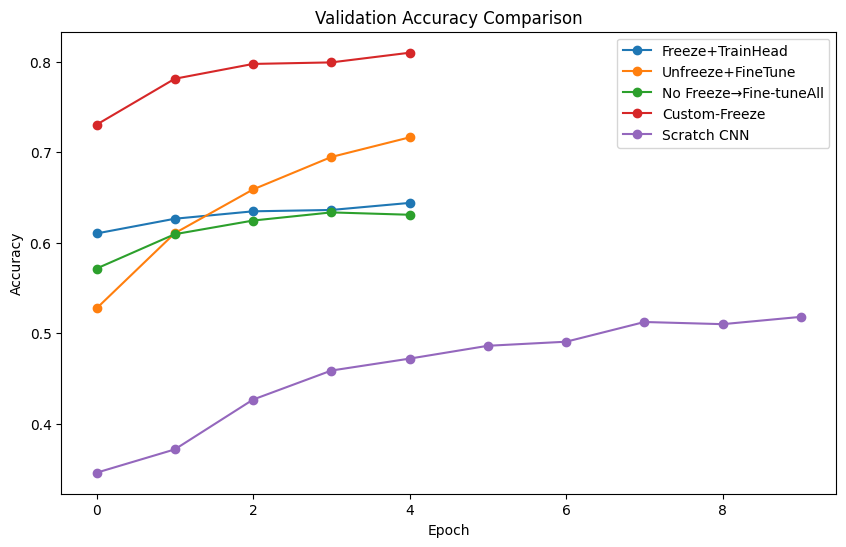

In [ ]:
# Compare all runs
plt.figure(figsize=(10,6))
plt.plot(history_fe.history['val_accuracy'], 'o-', label='Freeze+TrainHead')
plt.plot(history_ft.history['val_accuracy'], 'o-', label='Unfreeze+FineTune')
plt.plot(history_nf.history['val_accuracy'], 'o-', label='No Freeze→Fine-tuneAll')
plt.plot(history_cf.history['val_accuracy'], 'o-', label='Custom-Freeze')
plt.plot(history_s.history['val_accuracy'], 'o-', label='Scratch CNN')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

##Student Exercises: Extending the Transfer-Learning Lab
Swap in a New Pretrained Backbone

Replace `DenseNet121` with  `EfficientNetB0`, or `Xception` in your transfer-learning pipeline.

For each model, adjust the input size (e.g. EfficientNetB0 expects 224×224; VGG16 224×224; Xception at least 71×71).

Use `tf.image.resize` to reshape your CIFAR-10 images accordingly.

Train only the new head (5 epochs), then fine-tune (10 epochs at learning rate = 1e-5).

Try to incease epochs number and change learning rate

#Self study
#When using each scheme:

**Freeze All, Train Head Only**
- Your dataset is small (<10 K images)
- Classes are quite similar to ImageNet (natural objects, animals)

**Fine-Tuning After Head Training** (Unfreeze All)
- Your dataset is medium‐sized (10–100 K images)
- You see the validation accuracy climb for a few epochs and then flatten out—it and no longer improves

**Fine-Tuning from Scratch** (No Initial Freeze)
- You have a large dataset (≥100 K images)
- Your data is very different from ImageNet (e.g., medical scans)

**Custom Freezing** (Freeze First N Layers, Train Rest)
- You have intermediate data size (10–50 K)
- You want to reduce compute compared to full fine-tune

**Custom‐freezing** may works:

- Leverages Generic Low‐Level Features
The very first convolutional layers learn simple edge detectors, color blobs and texture filters. These are universal and almost never need changing. Freezing them preserves these reliable building blocks.

- Focuses Learning Capacity on Task‐Specific Layers
By unfreezing only the deeper layers, you allocate your limited data and gradient budget to learning the “high‐level” semantic features that actually distinguish your CIFAR classes, rather than re‐learning edges.